# Lab 10: Preparing files for flowmap.gl

In [1]:
import os
import pandas as pd
import geopandas as gpd

In [31]:
os.listdir('../resources')

['hdb_data_2023.csv.xz',
 'GE5230 Reflection Sheet.docx',
 'segamat',
 'ODIO_all_202306.csv.xz',
 'election',
 'citydata-date_2020-09-15.csv.xz',
 'master-plan-2019-planningarea.zip',
 'citydata-Queenstown-20200915.csv.xz',
 'election.zip',
 'citydata-head_sample.csv',
 'West_Region',
 'origin_destination_bus_202005.csv.xz',
 'hdb_data_2013.csv.xz',
 'bus_stop_loation.zip',
 '.ipynb_checkpoints',
 'MP14_SUBZONE_WEB_PL.zip',
 'train_station_location.zip',
 'origin_destination_train_202005.csv.xz',
 'master-plan-2019-subzone_landuse_area.zip']

In [32]:
df = pd.read_csv('../resources/origin_destination_bus_202005.csv.xz', index_col=0)
df.head()

,DAY_TYPE,TIME_PER_HOUR,PT_TYPE,ORIGIN_PT_CODE,DESTINATION_PT_CODE,TOTAL_TRIPS
YEAR_MONTH,,,,,,
2020-05,WEEKDAY,8,BUS,91099,92091,2
2020-05,WEEKENDS/HOLIDAY,8,BUS,91099,92091,3
2020-05,WEEKENDS/HOLIDAY,17,BUS,61039,10081,1
2020-05,WEEKENDS/HOLIDAY,7,BUS,31051,44009,3
2020-05,WEEKDAY,7,BUS,31051,44009,3


In [52]:
df2 = df[df['DAY_TYPE']=='WEEKDAY']
df2 = df2[df2['TIME_PER_HOUR']>=7]
df2 = df2[df2['TIME_PER_HOUR']<9]
df2 = df2.groupby(['ORIGIN_PT_CODE', 'DESTINATION_PT_CODE'])[['TOTAL_TRIPS']].sum().reset_index()
df2 = df2.rename(columns={'ORIGIN_PT_CODE': 'origin', 'DESTINATION_PT_CODE': 'dest', 'TOTAL_TRIPS': 'count'})
df2.head()

,origin,dest,count
0,1012,1112,27
1,1012,1113,55
2,1012,1211,22
3,1012,1311,58
4,1012,60021,25


<Axes: >

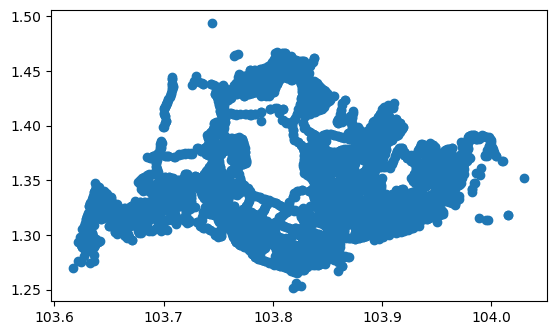

In [28]:
gdf = gpd.read_file('../resources/bus_stop_loation.zip')
gdf = gdf.to_crs('epsg:4326')
gdf.plot()

In [29]:
gdf.head()

,PTcode,desc,lat,lon,index_szon,OBJECTID,SUBZONE_NO,SUBZONE_N,SUBZONE_C,CA_IND,...,PLN_AREA_C,REGION_N,REGION_C,INC_CRC,FMEL_UPD_D,X_ADDR,Y_ADDR,SHAPE_Leng,SHAPE_Area,geometry
0,65539,Blk 224A,1.402291,103.893700,265.0,266.0,3.0,MATILDA,PGSZ03,N,...,PG,NORTH-EAST REGION,NER,14D0DB33976B7B81,2014-12-05,35089.9853,42728.2745,5361.915964,1.418284e+06,POINT (103.89370 1.40229)
1,98309,Carissa Pk,1.359960,103.964737,231.0,232.0,8.0,FLORA DRIVE,PRSZ08,N,...,PR,EAST REGION,ER,FA9C76B49B6D0C95,2014-12-05,42801.7349,37930.5489,3956.615777,9.449984e+05,POINT (103.96474 1.35996)
2,65541,Before Sumang Lane,1.403562,103.891200,265.0,266.0,3.0,MATILDA,PGSZ03,N,...,PG,NORTH-EAST REGION,NER,14D0DB33976B7B81,2014-12-05,35089.9853,42728.2745,5361.915964,1.418284e+06,POINT (103.89120 1.40356)
3,49159,Econ Group,1.437072,103.745813,288.0,289.0,5.0,RESERVOIR VIEW,SKSZ05,N,...,SK,NORTH REGION,NR,40050ADDFBCC870F,2014-12-05,18367.1710,45940.4868,10399.424485,3.284130e+06,POINT (103.74581 1.43707)
4,98311,Bef Mariam Wk,1.359306,103.968491,231.0,232.0,8.0,FLORA DRIVE,PRSZ08,N,...,PR,EAST REGION,ER,FA9C76B49B6D0C95,2014-12-05,42801.7349,37930.5489,3956.615777,9.449984e+05,POINT (103.96849 1.35931)


In [30]:
gdf.columns

Index(['PTcode', 'desc', 'lat', 'lon', 'index_szon', 'OBJECTID', 'SUBZONE_NO',
       'SUBZONE_N', 'SUBZONE_C', 'CA_IND', 'PLN_AREA_N', 'PLN_AREA_C',
       'REGION_N', 'REGION_C', 'INC_CRC', 'FMEL_UPD_D', 'X_ADDR', 'Y_ADDR',
       'SHAPE_Leng', 'SHAPE_Area', 'geometry'],
      dtype='object')

In [36]:
gdf['name'] = gdf['desc']
gdf['id'] = gdf['PTcode']

In [38]:
location_df = gdf[['id', 'name', 'lat', 'lon']].copy()
location_df.head()

,id,name,lat,lon
0,65539,Blk 224A,1.402291,103.893700
1,98309,Carissa Pk,1.359960,103.964737
2,65541,Before Sumang Lane,1.403562,103.891200
3,49159,Econ Group,1.437072,103.745813
4,98311,Bef Mariam Wk,1.359306,103.968491


In [53]:
df2.to_csv('../resources/flowmap_flow_202005.csv')

In [41]:
location_df.to_csv('../resources/flowmap_location_202005.csv')

In [42]:
len(location_df['id'].unique())

5134

In [44]:
len(location_df)

5135

In [46]:
temp = location_df.groupby('id')[['name']].count().reset_index()
temp[temp['name']>1]

,id,name
2652,52371,2


In [48]:
location_df[location_df['id']=='52371']

,id,name,lat,lon
937,52371,First Toa Payoh Pr Sch,1.33993,103.856516
938,52371,First Toa Payoh Pr Sch,1.33993,103.856516


In [50]:
location_df = location_df.drop(938)
len(location_df)

5134

In [51]:
location_df.to_csv('../resources/flowmap_location_202005.csv')